### ASSIGNEMENT-2 ON MAT 3141 (Applied Statistics & Probability) using Python


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#### 1.a) Relationship between Training Time and Model Accuracy


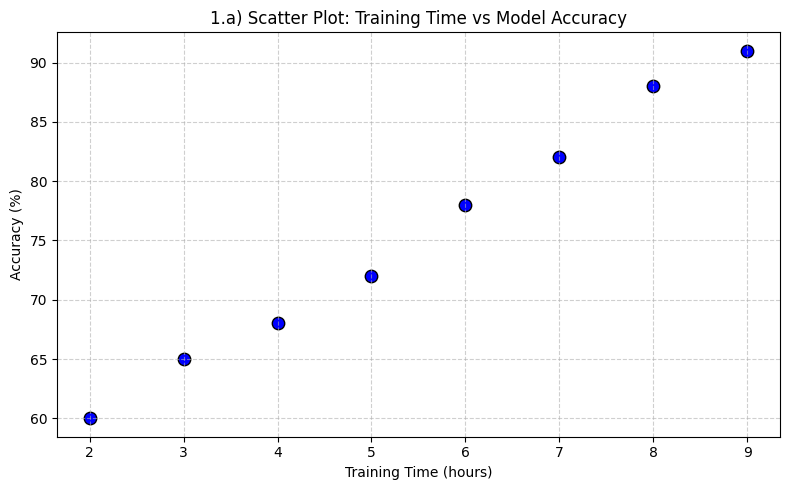

1.a) Karl Pearson Correlation Analysis:
  Pearson correlation coefficient (r) : 0.9974
  Coefficient of determination (r^2) : 0.9948

1.a) Interpretation:
  There is a very strong positive linear relationship between
  training time and model scores (r = 0.9974).
  About 99.48% of the variation in scores is
  explained by the training time.


In [2]:
# 1.a) Data: Training Time (hrs) vs Accuracy (%) for 8 AI models
hours = np.array([2, 3, 4, 5, 6, 7, 8, 9])
scores = np.array([60, 65, 68, 72, 78, 82, 88, 91])

# i) Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(hours, scores, color='blue', s=80, edgecolor='black')
plt.title('1.a) Scatter Plot: Training Time vs Model Accuracy')
plt.xlabel('Training Time (hours)')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ii) Karl Pearson correlation coefficient
r = np.corrcoef(hours, scores)[0, 1]
r_squared = r ** 2

print("1.a) Karl Pearson Correlation Analysis:")
print(f"  Pearson correlation coefficient (r) : {r:.4f}")
print(f"  Coefficient of determination (r^2) : {r_squared:.4f}")

# iii) Interpretation
if abs(r) >= 0.8:
    strength = "very strong"
elif abs(r) >= 0.6:
    strength = "strong"
elif abs(r) >= 0.4:
    strength = "moderate"
elif abs(r) >= 0.2:
    strength = "weak"
else:
    strength = "very weak"
direction = "positive" if r > 0 else "negative"

print("\n1.a) Interpretation:")
print(f"  There is a {strength} {direction} linear relationship between")
print(f"  training time and model scores (r = {r:.4f}).")
print(f"  About {r_squared*100:.2f}% of the variation in scores is")
print(f"  explained by the training time.")

#### 1.b) Linear Regression: GPU Cost vs AI Service Revenue


1.b) Linear Regression Model:
  Slope (b1)     : 2.0200
  Intercept (b0) : 0.7000
  Equation       : Revenue = 2.0200 * GPU_Cost + 0.7000


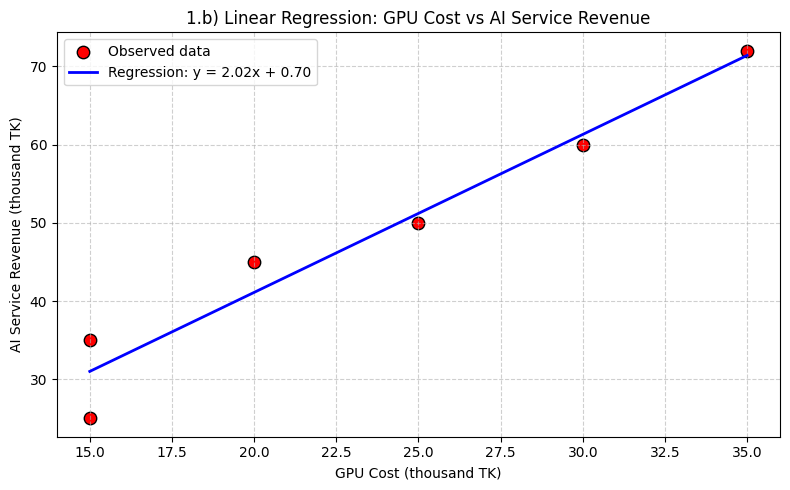


1.b) Prediction:
  When GPU Cost = 28 thousand TK,
  Predicted Revenue = 57.26 thousand TK

1.b) Interpretation of the Regression Model:
  - Correlation coefficient (r) : 0.9750
  - For every 1 thousand TK increase in GPU cost,
    income is expected to increase by 2.02 thousand TK.
  - The model explains 95.06% of the variation in income.


In [3]:
# 1.b) Data: GPU Cost and AI Service Revenue (in thousand TK)
hardware_cost = np.array([15, 15, 20, 25, 30, 35])
income = np.array([25, 35, 45, 50, 60, 72])

# i) Develop linear regression model
slope, intercept = np.polyfit(hardware_cost, income, 1)

print("1.b) Linear Regression Model:")
print(f"  Slope (b1)     : {slope:.4f}")
print(f"  Intercept (b0) : {intercept:.4f}")
print(f"  Equation       : Revenue = {slope:.4f} * GPU_Cost + {intercept:.4f}")

# ii) Plot the regression line with dataset
plt.figure(figsize=(8, 5))
plt.scatter(hardware_cost, income, color='red', s=80, edgecolor='black',
            label='Observed data')
plt.plot(hardware_cost, slope * hardware_cost + intercept, color='blue',
         linewidth=2, label=f'Regression: y = {slope:.2f}x + {intercept:.2f}')
plt.title('1.b) Linear Regression: GPU Cost vs AI Service Revenue')
plt.xlabel('GPU Cost (thousand TK)')
plt.ylabel('AI Service Revenue (thousand TK)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# iii) Predict income when GPU cost = 28 thousand TK
gpu_new = 28
predicted_income = slope * gpu_new + intercept
print("\n1.b) Prediction:")
print(f"  When GPU Cost = {gpu_new} thousand TK,")
print(f"  Predicted Revenue = {predicted_income:.2f} thousand TK")

# iv) Interpretation
corr = np.corrcoef(hardware_cost, income)[0, 1]
print("\n1.b) Interpretation of the Regression Model:")
print(f"  - Correlation coefficient (r) : {corr:.4f}")
print(f"  - For every 1 thousand TK increase in GPU cost,")
print(f"    income is expected to increase by {slope:.2f} thousand TK.")
print(
    f"  - The model explains {corr**2*100:.2f}% of the variation in income.")

#### 2.a) Variability Comparison Between Two Development Teams


2.a) Measures of Variability:
--- Team X ---
  Mean        : 12.50
  Median (Q2) : 12.50
  Q1          : 12.00
  Q3          : 13.00
  QD          : 0.50
  CQD         : 4.00%
  SD          : 1.05
  CV          : 8.39%

--- Team Y ---
  Mean        : 13.83
  Median (Q2) : 13.50
  Q1          : 10.50
  Q3          : 17.25
  QD          : 3.38
  CQD         : 25.00%
  SD          : 4.67
  CV          : 33.73%


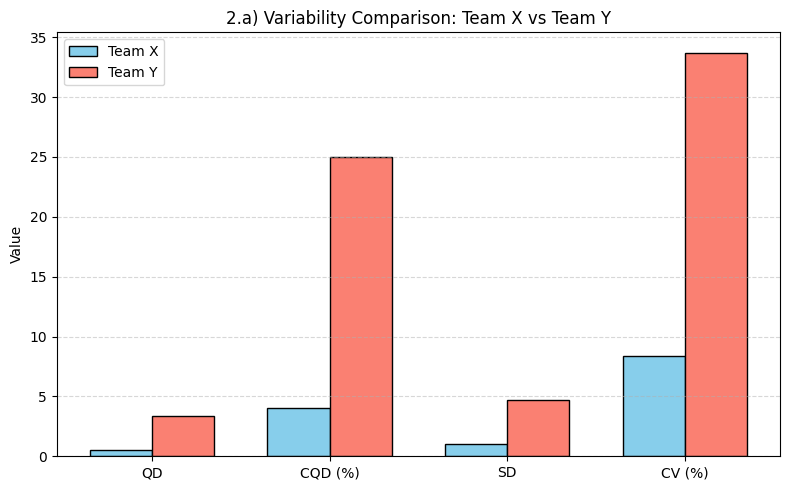


2.a) Consistency Decision:
  Team X CV = 8.39%,  Team Y CV = 33.73%
  => Team X is more consistent (lower CV).

2.a) Importance of Consistency in Agile Development:
  - Predictable velocity enables reliable sprint planning.
  - Stable delivery improves stakeholder trust.
  - Reduces risk of missed deadlines and burnout.
  - Makes burndown/burnup charts smoother and easier to read.
  - Facilitates continuous improvement through less variance to analyze.


In [4]:
# 2.a) Sprint completion times for Team X and Team Y
group_A = np.array([12, 13, 12, 11, 14, 13])
group_B = np.array([8, 10, 12, 15, 18, 20])


def dispersion_metrics(name, data):
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    qd = (q3 - q1) / 2
    cqd = (qd / median) * 100
    sd = np.std(data, ddof=1)
    mean = np.mean(data)
    cv = (sd / mean) * 100
    print(f"--- {name} ---")
    print(f"  Mean        : {mean:.2f}")
    print(f"  Median (Q2) : {median:.2f}")
    print(f"  Q1          : {q1:.2f}")
    print(f"  Q3          : {q3:.2f}")
    print(f"  QD          : {qd:.2f}")
    print(f"  CQD         : {cqd:.2f}%")
    print(f"  SD          : {sd:.2f}")
    print(f"  CV          : {cv:.2f}%")
    return cv, sd, qd, cqd


print("2.a) Measures of Variability:")
cv_X, sd_X, qd_X, cqd_X = dispersion_metrics("Team X", group_A)
print()
cv_Y, sd_Y, qd_Y, cqd_Y = dispersion_metrics("Team Y", group_B)

# Bar chart comparing the variability measures
labels = ['QD', 'CQD (%)', 'SD', 'CV (%)']
x_vals = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x_vals - width/2, [qd_X, cqd_X, sd_X, cv_X], width,
        label='Team X', color='skyblue', edgecolor='black')
plt.bar(x_vals + width/2, [qd_Y, cqd_Y, sd_Y, cv_Y], width,
        label='Team Y', color='salmon', edgecolor='black')
plt.xticks(x_vals, labels)
plt.ylabel('Value')
plt.title('2.a) Variability Comparison: Team X vs Team Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

# ii) Determine which team is more consistent
more_consistent = "Team X" if cv_X < cv_Y else "Team Y"
print("\n2.a) Consistency Decision:")
print(f"  Team X CV = {cv_X:.2f}%,  Team Y CV = {cv_Y:.2f}%")
print(f"  => {more_consistent} is more consistent (lower CV).")

# iii) Importance of consistency in Agile
print("\n2.a) Importance of Consistency in Agile Development:")
print("  - Predictable velocity enables reliable sprint planning.")
print("  - Stable delivery improves stakeholder trust.")
print("  - Reduces risk of missed deadlines and burnout.")
print("  - Makes burndown/burnup charts smoother and easier to read.")
print("  - Facilitates continuous improvement through less variance to analyze.")

#### 2.b) Box Plot and Outlier Detection for IoT Soil Moisture Data


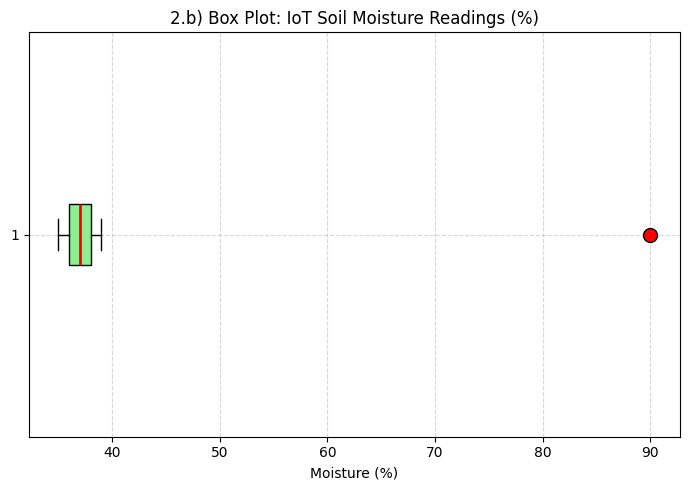

2.b) Outlier Detection (IQR Method):
  Q1        : 36.0
  Q2 (Med)  : 37.0
  Q3        : 38.0
  IQR       : 2.0
  Lower Fence: 33.0
  Upper Fence: 41.0
  Outliers detected: [90]

2.b) Interpretation:
  The reading 90% is a clear outlier - it is far above the upper
  fence (41%) of the IQR method. In an IoT smart-agriculture system,
  such an abnormal reading could trigger false irrigation decisions,
  waste water, or mask actual sensor faults. Pre-processing with
  outlier detection is essential before feeding data to the decision system.


In [5]:
# 2.b) IoT soil sensor_data sensor readings (10 readings)
sensor_data = np.array([35, 36, 37, 35, 38, 39, 36, 37, 90, 38])

# i) Draw a box plot
plt.figure(figsize=(7, 5))
plt.boxplot(sensor_data, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', edgecolor='black'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='red',
                            markersize=10, markeredgecolor='black'))
plt.title('2.b) Box Plot: IoT Soil Moisture Readings (%)')
plt.xlabel('Moisture (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ii) Detect anomalies using the IQR method
q1, q2, q3 = np.percentile(sensor_data, [25, 50, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
anomalies = sensor_data[(sensor_data < lower_bound) | (sensor_data > upper_bound)]

print("2.b) Outlier Detection (IQR Method):")
print(f"  Q1        : {q1}")
print(f"  Q2 (Med)  : {q2}")
print(f"  Q3        : {q3}")
print(f"  IQR       : {iqr}")
print(f"  Lower Fence: {lower_bound}")
print(f"  Upper Fence: {upper_bound}")
print(f"  Outliers detected: {anomalies.tolist()}")

# iii) Interpretation
print("\n2.b) Interpretation:")
print("  The reading 90% is a clear outlier - it is far above the upper")
print("  fence (41%) of the IQR method. In an IoT smart-agriculture system,")
print("  such an abnormal reading could trigger false irrigation decisions,")
print("  waste water, or mask actual sensor faults. Pre-processing with")
print("  outlier detection is essential before feeding data to the decision system.")